## Estimación de rutas óptimas

In [ ]:
# imports
import geopandas as gpd
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
## Solo es necesario camibar la dirección de edges y nodes según corresponda.

## Actual
#nodes = gpd.read_file('/Users/Angelo/Dropbox/VS codes/final output/df_nodes_all_v2.shp') ## red actual 
#edges = gpd.read_file('/Users/Angelo/Dropbox/VS codes/final output/df_edges_all_v2.shp') ## red actual 

## 1970   
#nodes = gpd.read_file('/Users/Angelo/Dropbox/VS codes/final output/nodes_1970_unificado_v2.shp')
#edges = gpd.read_file('/Users/Angelo/Dropbox/VS codes/final output/edges_1970_unificado_v2.shp')

## 1980 
nodes = gpd.read_file('/Users/Angelo/Dropbox/VS codes/final output/nodes_1980_unificado_v2.shp')
edges = gpd.read_file('/Users/Angelo/Dropbox/VS codes/final output/edges_1980_1986_unificado_v2.shp')


In [8]:
mask_r11 = (edges['duration_n'].isna()) & (edges['region_id'] == 11.0)  & (edges['speed'] >0) 
edges.loc[mask_r11, 'duration_n'] = edges['duration']

# 3. Reporte de cambios
cambios = mask_r11.sum()
print(f"--- Reporte de Ajuste Región 11 ---")
print(f"Tramos actualizados: {cambios}")
print(f"-----------------------------------")


--- Reporte de Ajuste Región 11 ---
Tramos actualizados: 17
-----------------------------------


In [9]:
edges['duration_n'] = edges['duration_n'].fillna(0)

In [10]:
## Definiciones relevantes para el análisis de redes
nodes['nodeID'] = nodes['nodeID'].astype(int)
edges['node_start'] = edges['node_start'].astype(int)
edges['node_end'] = edges['node_end'].astype(int)
edges['direction'] = edges['direction'].astype(int)
# para 1970 y 1980 se usa duration_n
edges['duration'] = edges['duration_n'].astype(float)

## Djkstra 

Partimos corrigiendo los 'NaN' de 'duration' para que el algóritmo funcione (no los tome como valores negativo, tipo NaN = -99)

In [ ]:
##########################################################################################
# Estmación de rtas NaN Panel actual 
##########################################################################################

### Codigo solo necesario cuando se estiman las rutas actuales para llenar NaN



# 1. Definición de coeficientes
alpha = 0  

delta_11 = 20.00307 # pavimento x nacional 
delta_12 = 20.00307 # pavimento x internacional 
delta_13 = 13.70996 # pavimento x principal 
delta_14 = 11.61777 # pavimento x secundarío 
delta_15 = 12.16745 # pavimento x inter regional 

delta_21 = 15.47629 # ripio x nacional
delta_22 = 15.47629 # ripio x internacional
delta_23 = 12.49887 # ripio x principal
delta_24 = 10.98063 # ripio x secundario
delta_25 = 9.989366 # ripio x inter regional

delta_33 = 13.36675 # tierra x principal 
delta_34 = 9.456447 # tierra x secundario
delta_35 = 8.416221 # tierra x inter regional

delta_4 = 6.603552    # ferrie 
delta_1_s = 10.09588  # solo carp == 1 con info 

# 2. Crear dummies (si no existen)
carp_dummies = pd.get_dummies(edges['carp'], prefix='carp')
clas_dummies = pd.get_dummies(edges['clas'], prefix='clas')

carp_dummies.columns = [col.replace('.0', '') for col in carp_dummies.columns]
clas_dummies.columns = [col.replace('.0', '') for col in clas_dummies.columns]

cols_existentes = set(edges.columns)
carp_dummies = carp_dummies[[c for c in carp_dummies.columns if c not in cols_existentes]]
clas_dummies = clas_dummies[[c for c in clas_dummies.columns if c not in cols_existentes]]

edges = pd.concat([edges, carp_dummies, clas_dummies], axis=1)

# 3. Definir máscara para tramos sin tiempo
mask = edges['duration'].isna()

# 4. Calcular velocidad estimada
edges['speed'] = (
    alpha
    + delta_11 * edges.get('carp_1', 0) * edges.get('clas_1', 0)
    + delta_12 * edges.get('carp_1', 0) * edges.get('clas_2', 0)
    + delta_13 * edges.get('carp_1', 0) * edges.get('clas_3', 0)
    + delta_14 * edges.get('carp_1', 0) * edges.get('clas_4', 0)
    + delta_15 * edges.get('carp_1', 0) * edges.get('clas_5', 0)
    + delta_21 * edges.get('carp_2', 0) * edges.get('clas_1', 0)
    + delta_22 * edges.get('carp_2', 0) * edges.get('clas_2', 0)
    + delta_23 * edges.get('carp_2', 0) * edges.get('clas_3', 0)
    + delta_24 * edges.get('carp_2', 0) * edges.get('clas_4', 0)
    + delta_25 * edges.get('carp_2', 0) * edges.get('clas_5', 0)
    + delta_33 * edges.get('carp_3', 0) * edges.get('clas_3', 0)
    + delta_34 * edges.get('carp_3', 0) * edges.get('clas_4', 0)
    + delta_35 * edges.get('carp_3', 0) * edges.get('clas_5', 0)
    + delta_4 * edges.get('carp_4', 0) 
    + delta_1_s * edges.get('carp_1', 0) * (
        1 - edges.get('clas_1', 0) - edges.get('clas_2', 0) - 
        edges.get('clas_3', 0) - edges.get('clas_4', 0) - edges.get('clas_5', 0)
    )
)

# 5. Aplicar cálculo de duración solo a los tramos con tiempo faltante
edges.loc[mask, 'duration'] = edges.loc[mask, 'length'] / edges.loc[mask, 'speed']

# 6. Relleno final de NaNs con 0 (opcional, según tu flujo original)
edges['duration'] = edges['duration'].fillna(0)


Ahora estimamos el algoritmo dijkstra despues de corregir los NaN y unificar las conecciones del país.

In [ ]:

# 1. Grafo Intrarregional
G = nx.DiGraph()

for _, row in edges.iterrows():
    u = str(row['start'])
    v = str(row['end'])
    w = float(row['duration'])
    d = int(row['direction'])
    
    if d == 1:
        G.add_edge(u, v, weight=w)
    else:
        G.add_edge(u, v, weight=w)
        G.add_edge(v, u, weight=w)

# 1.B Coser Fronteras Interregionales

# Unimos lógicamente las regiones a través de los nodos 'frontier'.
frontier_nodes = nodes[nodes['frontier'] == 1].copy()

# Cruce espacial estricto (hace match solo si las fronteras se chocan a menos de 10 metros de margen)
fronteras_joined = gpd.sjoin_nearest(
    frontier_nodes, frontier_nodes, 
    how='inner', 
    max_distance=10, 
    distance_col='dist'
)

# Sacamos autocoincidencias
cross_region = fronteras_joined[fronteras_joined['node_ID_left'] != fronteras_joined['node_ID_right']]

# Añadimos los puentes físicos al grafo (con tiempo de salto = 0 minutos)
links_agregados = 0
for _, row in cross_region.iterrows():
    u = str(row['node_ID_left'])
    v = str(row['node_ID_right'])
    
    # Cruce de frontera en ambos sentidos
    G.add_edge(u, v, weight=0.0)
    G.add_edge(v, u, weight=0.0)
    links_agregados += 1

print(f"-> ¡País conectado exitosamente! Se han cosido {links_agregados // 2} puntos fronterizos a la red.")

# 2. Centroides (poblacionales > 1.000.000)
centroids_df = nodes[nodes['nodeID'].astype(int) >= 1000000].copy()

centroids_df = centroids_df.drop_duplicates(subset=['COMUNA']).copy()

centroids_df = centroids_df[['node_ID', 'nodeID', 'COMUNA', 'region']]

# 3. Mapping origin to groups
mapping = centroids_df.groupby('node_ID')

# 4. Dijkstra Nacional
results = []
unique_node_IDs = centroids_df['node_ID'].unique()

for i, origin_id in enumerate(unique_node_IDs):
    
    if i % 10 == 0:
        print(f"Procesando {i}/{len(unique_node_IDs)}")
    
    if str(origin_id) not in G:
        continue
    
    lengths = nx.single_source_dijkstra_path_length(
        G,
        source=str(origin_id),
        weight='weight'
    )
    
    origin_rows = mapping.get_group(origin_id)
    
    for dest_id in unique_node_IDs:
        if origin_id == dest_id:
            continue
        
        # Ahora San Miguel a Castro te dará el viaje legítimo recorriendo todo el país
        time_val = lengths.get(str(dest_id), float('inf'))
        
        if dest_id in mapping.groups:
            dest_rows = mapping.get_group(dest_id)
            
            for _, o in origin_rows.iterrows():
                for _, d in dest_rows.iterrows():
                    
                    results.append({
                        'origin_node_ID': o['node_ID'],
                        'origin_COMUNA': o['COMUNA'],
                        'origin_region': o['region'],
                        
                        'destination_node_ID': d['node_ID'],
                        'destination_COMUNA': d['COMUNA'],
                        'destination_region': d['region'],
                        
                        'time_min': time_val
                    })

# 5. DataFrame final (Matriz Nacional Real)
df_results = pd.DataFrame(results)
display(df_results.head())


-> ¡País conectado exitosamente! Se han cosido 73 puntos fronterizos a la red.
Procesando 0/333
Procesando 10/333
Procesando 20/333
Procesando 30/333
Procesando 40/333
Procesando 50/333
Procesando 60/333
Procesando 70/333
Procesando 80/333
Procesando 90/333
Procesando 100/333
Procesando 110/333
Procesando 120/333
Procesando 130/333
Procesando 140/333
Procesando 150/333
Procesando 160/333
Procesando 170/333
Procesando 180/333
Procesando 190/333
Procesando 200/333
Procesando 210/333
Procesando 220/333
Procesando 230/333
Procesando 240/333
Procesando 250/333
Procesando 260/333
Procesando 270/333
Procesando 280/333
Procesando 290/333
Procesando 300/333
Procesando 310/333
Procesando 320/333
Procesando 330/333


,origin_node_ID,origin_COMUNA,origin_region,destination_node_ID,destination_COMUNA,destination_region,time_min
0,1000000,ALGARROBO,5,1000001,ALHUÉ,13,13580.431946
1,1000000,ALGARROBO,5,1000002,ALTO BIOBÍO,8,46603.118092
2,1000000,ALGARROBO,5,1000003,ALTO DEL CARMEN,3,51796.464554
3,1000000,ALGARROBO,5,1000004,ALTO HOSPICIO,1,114371.138251
4,1000000,ALGARROBO,5,1000005,ANCUD,10,80189.890131


In [13]:
df_results = df_results[df_results['origin_COMUNA'].notna()]

## Exportar resultados + chequeos

In [12]:
df_results = pd.DataFrame(results)
df_results.to_csv("/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/distancia/matriz_OD_1980.csv", index=False)
df_results.to_excel("/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/distancia/matriz_OD_1980.xlsx", index=False)

In [13]:

rutas_matrix = {
    '1970': '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/distancia/matriz_OD_1970.csv',
    '1980': '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/distancia/matriz_OD_1980.csv',
    'Actual': '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/distancia/matriz_OD_actual.csv'
}

rutas_edges = {
    '1970': '/Users/Angelo/Dropbox/VS codes/final output/edges_1970_unificado_v2.shp',
    '1980': '/Users/Angelo/Dropbox/VS codes/final output/edges_1980_1986_unificado_v2.shp',
    'Actual': '/Users/Angelo/Dropbox/VS codes/final output/df_edges_all_v2.shp'
}

stats = []

for year in rutas_matrix.keys():
    # Leemos resultados del Dijkstra en CSV
    df_od = pd.read_csv(rutas_matrix[year])
    
    # Cargamos el Shapefile real solo para sacarle la longitud a la lista de edges
    print(f"Contando calles para la década {year}...")
    edges_gdf = gpd.read_file(rutas_edges[year])
    n_edges = len(edges_gdf)
    
    valid = df_od[df_od['time_min'] < float('inf')].copy()
    valid['horas_reales'] = valid['time_min'] / 3600
    desc = valid['horas_reales'].describe()
    
    stats.append({
        'Periodo': year,
        'N° Edges (Calles)': n_edges,
        'Conectividad (%)': round((len(valid) / len(df_od)) * 100, 1),
        'Promedio (Horas)': round(desc['mean'], 1),
        'Mediana (Horas)': round(desc['50%'], 1),
        'Viaje más largo (Hrs)': round(desc['max'], 1)
    })

res_agrupado = pd.DataFrame(stats)
display(res_agrupado)


Contando calles para la década 1970...
Contando calles para la década 1980...
Contando calles para la década Actual...


,Periodo,N° Edges (Calles),Conectividad (%),Promedio (Horas),Mediana (Horas),Viaje más largo (Hrs)
0,1970,18576,100.0,24.9,13.4,201.2
1,1980,19810,100.0,18.2,11.2,146.6
2,Actual,30578,100.0,14.1,8.4,141.7


Cargando datos para KDE 1970...
Cargando datos para KDE 1980...
Cargando datos para KDE Actual...


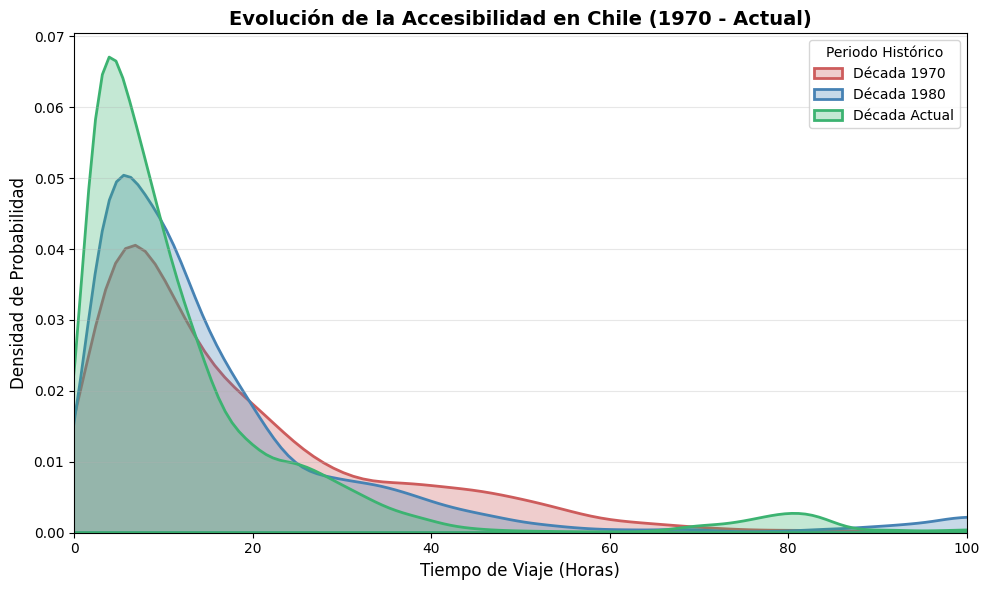

In [ ]:
# COMPARATIVA DE DENSIDAD DE KERNEL (1970 vs 1980 vs ACTUAL)

plt.figure(figsize=(10, 6))
colores = {'1970': 'indianred', '1980': 'steelblue', 'Actual': 'mediumseagreen'}

# Iteramos sobre las rutas que ya definiste
for year, path in rutas_matrix.items():
    print(f"Cargando datos para KDE {year}...")
    df_temp = pd.read_csv(path)
    
    # Filtrar infinitos y convertir a horas
    df_temp = df_temp[df_temp['time_min'] < float('inf')].copy()
    df_temp['horas'] = df_temp['time_min'] / 3600
    
    # Dibujar el Kernel Density Estimate (KDE)
    sns.kdeplot(
        df_temp['horas'], 
        label=f'Década {year}', 
        color=colores[year], 
        fill=True, 
        alpha=0.3,
        linewidth=2
    )

# Configuración estética
plt.title('Evolución de la Accesibilidad en Chile (1970 - Actual)', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo de Viaje (Horas)', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Periodo Histórico')

# Limitar X si hay outliers muy extremos para ver mejor la masa principal
plt.xlim(0, 100) # Ajustado a 100 horas para ver el grueso del país

plt.tight_layout()
plt.show()
